# **MODELOS DE LINGUAGEM E EMBEDDINGS**

## **MODELOS DE LINGUAGEM**

Um modelo de linguagem estatístico descreve o quão provável é uma sequência de palavras no idioma que ele modela. Ele faz isso atribuindo uma probabilidade a cada sequência de palavras possível. Uma sequência correta e comum de palavras recebe uma alta probabilidade, e uma sequência incorreta ou incomum de palavras recebe uma baixa probabilidade.

No material anterior, a rede feita para autocompletar textos faz exatamente isso, porém, ela faz usando caracteres como blocos de construção, enquanto um modelo de linguagem costuma utilizar palavras como blocos de construção.

*Um modelo de linguagem estatístico é tipicamente formulado em termos de probabilidades condicionais, onde a probabilidade da próxima palavra em uma sequência é condicionada a todas as palavras anteriores na sequência.*

A figura abaixo exemplifica o *beam search*, usado também no material passado, baseado em palavras. Com o *beam size* de 2 e alimentando a rede com a palavra *"Deep"*, o modelo pode atribuir uma alta probabilidade às seguintes palavras: *"learning"* e *"dish"*. Outras palavras (por exemplo, *"heaven", "bicycle", "talked"*) receberão uma baixa probabilidade. O raciocínio aqui é que, embora *"deep heaven"* e *"deep bicycle"* sejam frases plausíveis, elas parecem improváveis devido aos significados das palavras. É importante notar que podemos construir múltiplos modelos de linguagem para um determinado idioma, dependendo do contexto em que será usado. Em geral, as propriedades do modelo de linguagem dependem do **corpus de texto** do qual ele é derivado.

*Corpus, nesse contexto, refere-se ao conjunto de textos que serve como banco de dados de linguagem para análise, treinamento e/ou avaliações de modelos.*

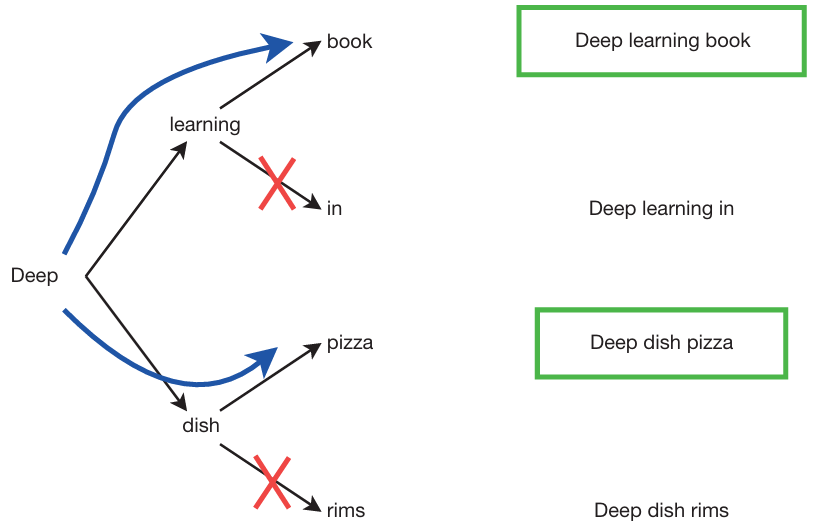 *Beam search baseado em palavras*


Abaixo, serão citados dois exemplos de muitos casos de uso de um modelo de linguagem no campo do processamento de linguagem natural.

O primeiro exemplo é o reconhecimento de fala. Como comentado no material anterior, no contexto das *RNNs Bidirecionais*, pode ser útil olhar tanto para as palavra históricas quanto para as futuras em uma frase ao fazer o reconhecimento de fala. Um modelo de reconhecimento de fala, por exemplo, pode não compreender corretamente uma frase dita. Nesse caso, podemos aplicar um modelo de linguagem para selecionar a frase que for mais provável de ter sido dita, melhorando drasticamente a qualidade do reconhecimento de fala.

O segundo exemplo é a tradução automática de linguagem natural, onde o modelo de linguagem desempenha um grande papel. Primeiro, várias traduções candidatas são produzidas usando uma de várias técnicas existentes. Uma dessas técnicas é primeiro fazer uma tradução palavra por palavra e, em seguida, criar diferentes permutações de como as palavras são ordenadas (diferentes idiomas geralmente têm diferentes ordens de palavras). Um modelo de linguagem pode então ser usado para identificar a tradução candidata mais provável.

*OBS.: Esses exemplos acima ainda são muitos simples em relação ao que as redes mais atuais fazem nessas áreas.* 

### **EXEMPLOS DE ALGUNS MODELOS DE LINGUAGEM**

#### **n-GRAM**

É um modelo de linguagem estatístico simples. Como mecionado acima, um modelo de linguagem tenta resolver o problema de fornecer uma probabilidade para cada palavra em um vocabulário, dada uma sequência de palavras históricas. O modelo do *n-gram* aproxima isso considerando apenas as (n-1) palavras mais recentes, em vez de usar todas as palavras anteriores. Essas (n-1) palavras históricas mais a próxima palavra prevista pelo modelo formam uma sequência de *n* palavras, conhecida como *"n-gram"*, que dá nome ao modelo.

Esse *n* é um hiperparâmetro escolhido antes de treinar o modelo. Um exemplo desse modelo, que é amplamente conhecido, é o *bigram*, quando o n é igual a 2. Esse modelo é construído contando todos os diferentes bigramas no *corpus* de treinamento e, em seguida, baseando a previsão na frequência que cada bigrama aparece. Como exemplo, considere a seuquência de palavras "Quanto mais eu leio, mais eu aprendo, e eu gosto disso mais do que qualquer outra coisa." Para simplificar, ignoramos a pontuação e convertemos todos caracteres para minúsculos. Com isso podemos construir a seguinte lista de bigramas: /quanto mais/, /mais eu/, /eu leio/, /leio mais/, /mais eu/, /eu aprendo/, e assim por diante até /outra coisa/.

Observa-se que o bigrama /mais eu/ aparece mais de uma vez, os bigramas não idênticos /eu leio/, /eu aprendo/, /eu gosto/ e /mais eu/, /mais do/ têm a mesma palavra inicial. OS bigramas estão representados na tabela abaixo, ordenados alfabeticamente.

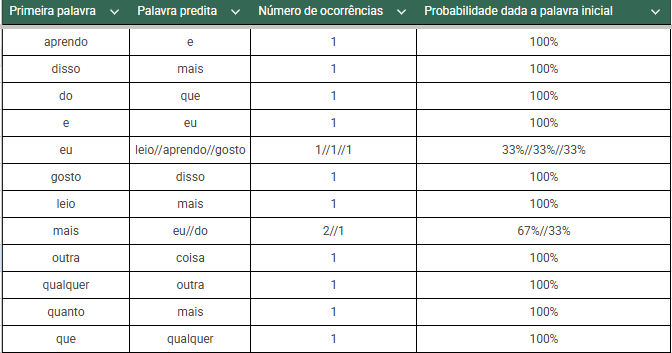 *Os bigramas*

A partir dessa tabela, conseguimos, dada uma palavra inicial, prever a próxima palavra. Por exemplo, se nos for dada a palavra *e*, nosso modelo bigrama prevê que a probabilidade da próxima palavra ser *eu* é de 100% e a probabilidade das outras palavras é 0%. Se a primeira palavra for *mais*, o modelo irá prever uma probabilidade de 67% para a palavra *eu* e 33% para a palavra *do*.

Com isso, nota-se que o modelo de bigrama é limitado por não capturar dependências de longo prazo. Por exemplo, se treinarmos o modelo nas frases “the boy reads,” “the girl reads,” e “the boy and girl read,” e depois apresentarmos “the boy and girl” como uma sequência inicial, o modelo bigrama ignorará “the boy and” e preverá a próxima palavra com base apenas na palavra *girl*. Sua probabilidade para *reads* é de 50%, e sua probabilidade para *read* é de 50%, embora o contexto mais longo deixe claro que a palavra *read* deveria ser mais provável. A solução óbvia é aumentar o valor de n. Podemos, com isso, criar um modelo 5-grama, isso permite que o modelo aumente sua habilidade de capturar essas dependências de longo prazo, porém, tem a desvantagem de que serão necessários muito mais dados de treinamento para capturar 5-gramas suficientes para tornar o modelo bom. Se a sequência inicial não puder ser encontrada na tabela, então o modelo prevê 0%, o que é uma limitação significativa do modelo n-grama básico. Isso é agravado pelo fato de que quanto mais longos os n-grmas, menor é a chance de que a sequência passada pro modelo seja exatamente igual a uma sequência no *corpus* de treinamento. Por exemplo, o *corpus* de treinamento pode ter contido a sequência “the boys and girls read,” mas o modelo ainda não pode prever nada quando apresentado à sequência de entrada “the boy and girl” porque *boy* e *girl* estão agora no singular. Ainda assim, o modelo n-grama básico demonstrou ser útil, e existem várias extensões que abordam algumas de suas deficiências.